# Cowboy Outfit Detection with YOLOv8

## What are we building?

We want to build a model that looks at a photo and draws bounding boxes around cowboy-related items: **belt**, **boot**, **cowboy_hat**, **jacket**, and **sunglasses**.

This is called **Object Detection** — different from image classification (which just says "is there a cowboy hat?"), detection also tells you *where* in the image the object is.

## Why YOLO?

**YOLO** (You Only Look Once) is a family of fast, accurate object detection models. Instead of scanning an image many times with a sliding window, YOLO looks at the entire image once and predicts all bounding boxes simultaneously. That makes it very fast.

We'll use **YOLOv8** from the `ultralytics` library — the latest and most user-friendly version.

## Roadmap

1. Install dependencies
2. Explore the dataset (understand what we have)
3. Visualize images and annotations
4. Convert data from COCO format → YOLO format
5. Create the dataset config file
6. Train the model
7. Evaluate results
8. Run inference on new images

---
## Step 1 — Install Dependencies

`ultralytics` is the official YOLOv8 package. It installs PyTorch and everything else we need under the hood.

In [12]:
# Install the ultralytics package which gives us YOLOv8
# The -q flag means 'quiet' — less verbose output
!pip install ultralytics -q

---
## Step 2 — Explore the Dataset

Before training anything, always understand your data. Surprises in the data are the #1 source of bad model performance.

### Dataset format: COCO

Our training labels are in **COCO format** — a single JSON file that describes:
- A list of **images** (file names, dimensions)
- A list of **annotations** (one per object instance, with a bounding box)
- A list of **categories** (class names)

The bounding box in COCO is `[x_min, y_min, width, height]` in **pixel coordinates**.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')
# Copy and unzip datasets to local disk (fast I/O during training)
!cp -r /content/drive/MyDrive/kaggle_datasets/cowboyoutfits.zip /content/
!unzip -q /content/cowboyoutfits.zip -d /content/cowboyoutfits/ #unzip to '/content/cowboyoutfits/
!ls /content/cowboyoutfits/

In [ ]:
import json
from pathlib import Path

DATA_DIR = Path('/content/cowboyoutfits')

# Load the training annotations
with open(DATA_DIR / 'train.json') as f:
    coco = json.load(f)

print('Top-level keys:', list(coco.keys()))
print(f"Images      : {len(coco['images'])}")
print(f"Annotations : {len(coco['annotations'])}")
print(f"Categories  : {len(coco['categories'])}")

Top-level keys: ['info', 'images', 'annotations', 'categories']
Images      : 3062
Annotations : 5594
Categories  : 5


In [14]:
# What classes (categories) do we have?
print('Classes:')
for cat in coco['categories']:
    print(f"  id={cat['id']:4d}  name={cat['name']}")

Classes:
  id=  87  name=belt
  id=1034  name=sunglasses
  id= 131  name=boot
  id= 318  name=cowboy_hat
  id= 588  name=jacket


In [15]:
# How many annotations per class?
# This tells us if the dataset is balanced or if some classes are rare.
# Class imbalance can hurt model performance on rare classes.
from collections import Counter, defaultdict

# Build a lookup: category_id -> name
id_to_name = {cat['id']: cat['name'] for cat in coco['categories']}

counts = Counter(ann['category_id'] for ann in coco['annotations'])

print('Annotations per class:')
for cat_id, count in counts.most_common():
    print(f"  {id_to_name[cat_id]:15s}: {count}")

Annotations per class:
  sunglasses     : 2330
  jacket         : 2195
  cowboy_hat     : 595
  boot           : 449
  belt           : 25


In [16]:
# Look at a sample image entry and a sample annotation
print('Sample image entry:')
print(json.dumps(coco['images'][0], indent=2))

print('\nSample annotation entry:')
print(json.dumps(coco['annotations'][0], indent=2))

Sample image entry:
{
  "id": 9860841628484337660,
  "file_name": "88d8bf3754317ffc.jpg",
  "neg_category_ids": [
    434
  ],
  "pos_category_ids": [
    69,
    161,
    216,
    277,
    433
  ],
  "width": 1024,
  "height": 681,
  "source": "OpenImages"
}

Sample annotation entry:
{
  "id": 12550146,
  "image_id": 15526467552013451612,
  "freebase_id": "/m/017ftj",
  "category_id": 1034,
  "iscrowd": false,
  "bbox": [
    102.49,
    181.12,
    137.08,
    97.92
  ],
  "area": 13423.09
}


**Understanding the annotation fields:**
- `image_id` — links this annotation to its image
- `category_id` — which class this object belongs to
- `bbox` — `[x_min, y_min, width, height]` in pixels
- `area` — width × height of the box (useful for filtering tiny boxes)
- `iscrowd` — if `True`, this annotation covers a crowd of objects (we'll skip these)

**Examine the Valid and Test Set**

In [ ]:
import csv
from pathlib import Path

IMAGES_DIR = DATA_DIR / 'images'

# Count total images in folder
all_images = set(p.name for p in IMAGES_DIR.glob('*.jpg'))
print(f'Total images in folder : {len(all_images)}')

# Load valid.csv and test.csv
with open(DATA_DIR / 'valid.csv') as f:
    valid_files = [row['file_name'] for row in csv.DictReader(f)]

with open(DATA_DIR / 'test.csv') as f:
    test_files = [row['file_name'] for row in csv.DictReader(f)]

print(f'Images in valid.csv    : {len(valid_files)}')
print(f'Images in test.csv     : {len(test_files)}')

# Check if CSV images exist in folder
valid_missing = [f for f in valid_files if f not in all_images]
test_missing  = [f for f in test_files  if f not in all_images]

print(f'\nMissing from valid.csv : {len(valid_missing)}')
print(f'Missing from test.csv  : {len(test_missing)}')

if valid_missing:
    print('Sample missing valid:', valid_missing[:3])
if test_missing:
    print('Sample missing test: ', test_missing[:3])

Total images in folder : 4879
Images in valid.csv    : 999
Images in test.csv     : 818

Missing from valid.csv : 0
Missing from test.csv  : 0


In [30]:
# from PIL import Image
# import random

# sample = random.choice(list(IMAGES_DIR.glob('*.jpg')))
# img = Image.open(sample)
# print(f'File : {sample.name}')
# print(f'Size : {img.size}  (width x height)')
# print(f'Mode : {img.mode}')

from PIL import Image
from pathlib import Path

sizes = []
for img_path in IMAGES_DIR.glob('*.jpg'):
    img = Image.open(img_path)
    sizes.append(img.size)

widths  = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print(f'Width  — min: {min(widths)}, max: {max(widths)}, avg: {sum(widths)//len(widths)}')
print(f'Height — min: {min(heights)}, max: {max(heights)}, avg: {sum(heights)//len(heights)}')

Width  — min: 309, max: 3264, avg: 938
Height — min: 305, max: 4912, avg: 819


---
## Step 3 — Visualize Images and Annotations

Never skip visualization. It lets you sanity-check that your bounding boxes are correct and that images look as expected.

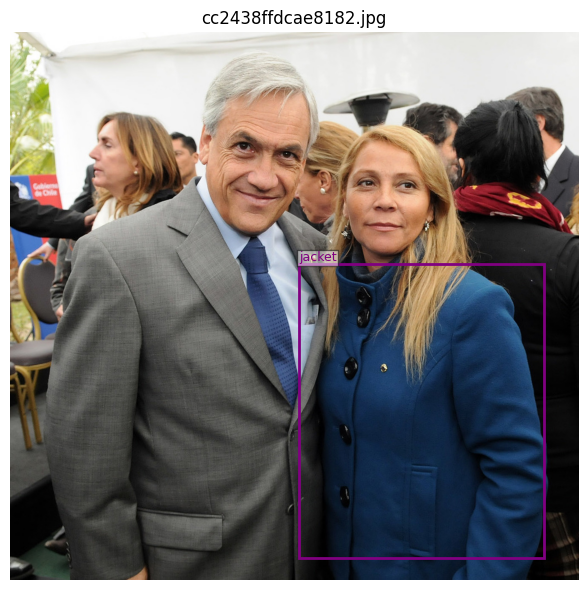

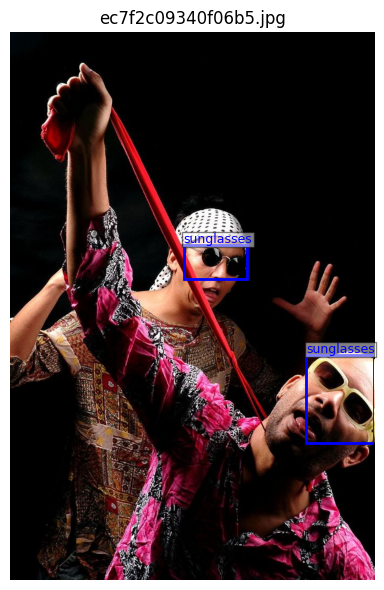

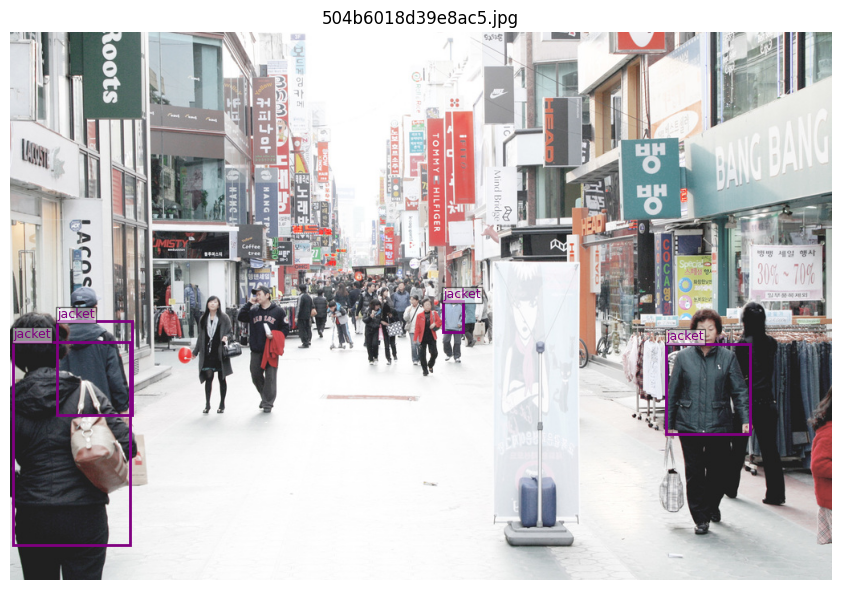

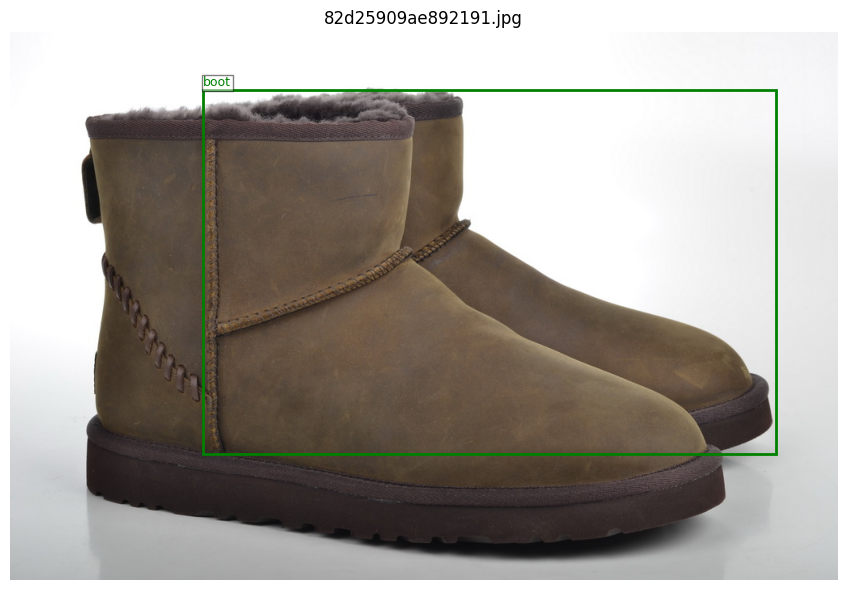

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import random

# Build a lookup: image_id -> list of annotations for that image
img_to_anns = defaultdict(list)
for ann in coco['annotations']:
    img_to_anns[ann['image_id']].append(ann)

# One color per class for nicer visualization
COLORS = {
    'belt':       'red',
    'sunglasses': 'blue',
    'boot':       'green',
    'cowboy_hat': 'orange',
    'jacket':     'purple',
}

def show_image_with_boxes(img_info, annotations):
    img_path = DATA_DIR / 'images' / img_info['file_name']
    img = Image.open(img_path)

    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(img)

    for ann in annotations:
        if ann['iscrowd']:
            continue  # skip crowd annotations
        x, y, w, h = ann['bbox']  # COCO format: x_min, y_min, width, height
        name = id_to_name[ann['category_id']]
        color = COLORS[name]

        # Draw rectangle
        rect = patches.Rectangle((x, y), w, h,
                                   linewidth=2, edgecolor=color, facecolor='none')
        ax.add_patch(rect)

        # Draw label
        ax.text(x, y - 4, name, color=color, fontsize=9,
                bbox=dict(facecolor='white', alpha=0.5, pad=1))

    ax.axis('off')
    plt.title(img_info['file_name'])
    plt.tight_layout()
    plt.show()

# Show 4 random training images that have annotations
annotated_imgs = [img for img in coco['images'] if img_to_anns[img['id']]]
for img_info in random.sample(annotated_imgs, 4):
    show_image_with_boxes(img_info, img_to_anns[img_info['id']])

In [19]:
# Define a consistent ordering of our 5 classes.
# The index position here becomes the YOLO class ID (0-indexed).
CLASS_NAMES = ['belt', 'boot', 'cowboy_hat', 'jacket', 'sunglasses']

# Build reverse lookup: category_id -> yolo class index
name_to_idx    = {name: i for i, name in enumerate(CLASS_NAMES)}
cat_id_to_yolo = {cat['id']: name_to_idx[cat['name']] for cat in coco['categories']}

print('Category ID -> YOLO class index mapping:')
for cat in coco['categories']:
    print(f"  COCO id {cat['id']:4d} ({cat['name']:15s}) -> YOLO class {cat_id_to_yolo[cat['id']]}")

Category ID -> YOLO class index mapping:
  COCO id   87 (belt           ) -> YOLO class 0
  COCO id 1034 (sunglasses     ) -> YOLO class 4
  COCO id  131 (boot           ) -> YOLO class 1
  COCO id  318 (cowboy_hat     ) -> YOLO class 2
  COCO id  588 (jacket         ) -> YOLO class 3


---
## Step 4 — Convert COCO Format → YOLO Format

### Why convert?

YOLOv8 doesn't read COCO JSON files directly. It expects labels in a specific text format:

- One `.txt` file **per image**, with the same base name (e.g., `cat.jpg` → `cat.txt`)
- Each line in the `.txt` = one object: `class_id  cx  cy  w  h`
- All values are **normalized** (divided by image width/height), so they are between 0 and 1
- The bounding box center is used, not the top-left corner

### COCO → YOLO conversion formula

```
COCO bbox:  [x_min, y_min, box_w, box_h]  (pixels)

cx = (x_min + box_w / 2) / image_width
cy = (y_min + box_h / 2) / image_height
w  = box_w / image_width
h  = box_h / image_height
```

### Class index remapping

YOLO expects class IDs to be **0-indexed integers** (0, 1, 2, ...).  
COCO category IDs are arbitrary numbers (87, 131, 318, ...), so we remap them.

In [21]:
# Build lookup: image_id -> image info (we need width/height for normalization)
img_id_to_info = {img['id']: img for img in coco['images']}

# Create output directory for YOLO labels
# YOLO replaces 'images' with 'labels' in the path to find label files:
#   data/images/foo.jpg  ->  data/labels/foo.txt
LABELS_DIR = DATA_DIR / 'labels'
LABELS_DIR.mkdir(parents=True, exist_ok=True)

skipped = 0
written = 0

# Loop over each image and write its label file
for img_id, anns in img_to_anns.items():
    img_info = img_id_to_info[img_id]
    img_w = img_info['width']
    img_h = img_info['height']

    lines = []
    for ann in anns:
        if ann['iscrowd']:
            skipped += 1
            continue  # YOLO doesn't support crowd annotations

        x_min, y_min, box_w, box_h = ann['bbox']

        # Convert to YOLO normalized center format
        cx = (x_min + box_w / 2) / img_w
        cy = (y_min + box_h / 2) / img_h
        w  = box_w / img_w
        h  = box_h / img_h

        # Clamp to [0, 1] to guard against any floating point edge cases
        cx, cy, w, h = [max(0.0, min(1.0, v)) for v in (cx, cy, w, h)]

        yolo_class = cat_id_to_yolo[ann['category_id']]
        lines.append(f"{yolo_class} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")
        written += 1

    # Write one .txt file per image (empty file = image has no objects)
    stem = Path(img_info['file_name']).stem
    label_path = LABELS_DIR / f"{stem}.txt"
    label_path.write_text('\n'.join(lines))

print(f"Labels written : {written}")
print(f"Crowd skipped  : {skipped}")
print(f"Label files    : {len(list(LABELS_DIR.glob('*.txt')))}")

Labels written : 5594
Crowd skipped  : 0
Label files    : 3062


In [22]:
# Sanity check: print the label file for the first annotated image
sample_img  = annotated_imgs[0]
stem        = Path(sample_img['file_name']).stem
label_path  = LABELS_DIR / f"{stem}.txt"

print(f"Image: {sample_img['file_name']}  ({sample_img['width']}x{sample_img['height']})")
print(f"Label file contents:")
print(label_path.read_text())
print()
print('Each row: class_id  cx  cy  width  height  (all normalized to 0-1)')

Image: 88d8bf3754317ffc.jpg  (1024x681)
Label file contents:
3 0.457500 0.619361 0.448750 0.759398

Each row: class_id  cx  cy  width  height  (all normalized to 0-1)


In [23]:
# Sanity check: print the label file for the first annotated image
sample_img  = annotated_imgs[0]
stem        = Path(sample_img['file_name']).stem
label_path  = LABELS_DIR / f"{stem}.txt"

print(f"Image: {sample_img['file_name']}  ({sample_img['width']}x{sample_img['height']})")
print(f"Label file contents:")
print(label_path.read_text())
print()
print('Each row: class_id  cx  cy  width  height  (all normalized to 0-1)')

Image: 88d8bf3754317ffc.jpg  (1024x681)
Label file contents:
3 0.457500 0.619361 0.448750 0.759398

Each row: class_id  cx  cy  width  height  (all normalized to 0-1)


In [24]:
import random, csv

# Split train.json 80/20
all_imgs = coco['images'].copy()
random.seed(42)
random.shuffle(all_imgs)

split = int(0.8 * len(all_imgs))
train_imgs = all_imgs[:split]
val_imgs   = all_imgs[split:]

print(f'Train images (labeled) : {len(train_imgs)}')
print(f'Val images   (labeled) : {len(val_imgs)}')

# Load Kaggle inference sets (no labels)
with open(DATA_DIR / 'valid.csv') as f:
    kaggle_valid = [row['file_name'] for row in csv.DictReader(f)]

with open(DATA_DIR / 'test.csv') as f:
    kaggle_test = [row['file_name'] for row in csv.DictReader(f)]

print(f'\nKaggle valid (no labels): {len(kaggle_valid)}')
print(f'Kaggle test  (no labels): {len(kaggle_test)}')

Train images (labeled) : 2449
Val images   (labeled) : 613

Kaggle valid (no labels): 999
Kaggle test  (no labels): 818


In [ ]:
# Write train/val path lists for YOLO training
train_paths = [str((IMAGES_DIR / img['file_name']).resolve()) for img in train_imgs]
val_paths   = [str((IMAGES_DIR / img['file_name']).resolve()) for img in val_imgs]

(DATA_DIR / 'train.txt').write_text('\n'.join(train_paths))
(DATA_DIR / 'val.txt').write_text('\n'.join(val_paths))

# Store Kaggle inference paths for later use
kaggle_valid_paths = [str((IMAGES_DIR / f).resolve()) for f in kaggle_valid]
kaggle_test_paths  = [str((IMAGES_DIR / f).resolve()) for f in kaggle_test]

print(f'train.txt   : {len(train_paths)} images')
print(f'val.txt     : {len(val_paths)} images')
print(f'Kaggle valid: {len(kaggle_valid_paths)} images')
print(f'Kaggle test : {len(kaggle_test_paths)} images')

train.txt   : 2449 images
val.txt     : 613 images
Kaggle valid: 999 images
Kaggle test : 818 images


---
## Step 6 — Create the Dataset YAML Config

YOLOv8 needs a small YAML file that tells it:
- Where the training images are
- Where the validation images are  
- How many classes and what they're named

The class name order in this file **must match** the class IDs in our `.txt` label files.

In [26]:
import yaml

abs_data_dir = DATA_DIR.resolve()

dataset_config = {
    'path':  str(abs_data_dir),
    'train': str(abs_data_dir / 'train.txt'),
    'val':   str(abs_data_dir / 'val.txt'),
    'nc':    len(CLASS_NAMES),   # number of classes
    'names': CLASS_NAMES,        # list of class names (index = YOLO class ID)
}

yaml_path = Path('cowboy.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(dataset_config, f, default_flow_style=False)

print('cowboy.yaml contents:')
print(yaml_path.read_text())

cowboy.yaml contents:
names:
- belt
- boot
- cowboy_hat
- jacket
- sunglasses
nc: 5
path: /Users/rongrong/codelab/d2l-zh/pytorch/cowboyoutfits/data
train: /Users/rongrong/codelab/d2l-zh/pytorch/cowboyoutfits/data/train.txt
val: /Users/rongrong/codelab/d2l-zh/pytorch/cowboyoutfits/data/val.txt



---
## Step 7 — Train the Model

### Choosing a model size

YOLOv8 comes in 5 sizes. We'll use `yolov8s` (small) — a good balance:

| Model     | Speed  | Accuracy | Parameters |
|-----------|--------|----------|------------|
| yolov8n   | fastest| lowest   | ~3M        |
| **yolov8s** | **fast** | **good** | **~11M** |
| yolov8m   | medium | better   | ~26M       |
| yolov8l   | slow   | high     | ~44M       |
| yolov8x   | slowest| highest  | ~68M       |

### Transfer Learning

We load a model **pretrained on COCO** (a large 80-class dataset) and fine-tune it on our 5 classes. This is called **transfer learning** — the model already knows how to detect edges, shapes, and objects in general. We just steer it toward our specific classes. This dramatically speeds up training and improves accuracy vs. starting from scratch.

### Key training parameters

- `epochs` — how many full passes through the dataset. More = better, up to a point
- `imgsz` — input image size (pixels). Larger = more detail but slower and more memory
- `batch` — images per training step. Larger = more stable gradients, but needs more GPU memory
- `patience` — stop early if validation accuracy stops improving (prevents overfitting)

In [ ]:
import shutil
from pathlib import Path

DRIVE_BEST_PT = '/content/drive/MyDrive/cowboyoutfits/best.pt'
Path(DRIVE_BEST_PT).parent.mkdir(parents=True, exist_ok=True)

def save_best_to_drive(trainer):
    """Called by YOLO whenever it saves a checkpoint. Copies best.pt to Drive only."""
    best_src = Path(trainer.best)
    if best_src.exists():
        shutil.copy(best_src, DRIVE_BEST_PT)
        print(f'  [Drive] Saved best.pt (epoch {trainer.epoch}, fitness={trainer.fitness:.4f})')

print('Drive mounted. Callback ready.')


In [ ]:
from ultralytics import YOLO

# Load pretrained YOLOv8s — weights are downloaded automatically (~22MB)
model = YOLO('yolov8s.pt')

# Register callback: copies best.pt to Drive whenever YOLO updates it
model.add_callback('on_model_save', save_best_to_drive)

# Train!
results = model.train(
    data='cowboy.yaml',      # our dataset config
    epochs=50,               # train for up to 50 epochs
    imgsz=640,               # standard YOLO input size
    batch=16,                # reduce to 8 if you run out of memory
    patience=10,             # early stop if no improvement for 10 epochs
    name='cowboy_yolov8s',   # experiment name — results saved to runs/detect/
    exist_ok=True,           # overwrite previous run with the same name
)

print('Training complete!')


---
## Step 8 — Evaluate Results

### Understanding the metrics

- **Precision** — of all boxes the model predicted, what fraction were actually correct?
- **Recall** — of all real objects in the images, what fraction did the model find?
- **mAP@0.5** — mean Average Precision using IoU threshold 0.5. A predicted box must overlap the ground truth by ≥50% to count as correct. Average of AP across all 5 classes.
- **mAP@0.5:0.95** — stricter version: averages mAP at thresholds 0.5, 0.55, ..., 0.95

A good mAP@0.5 for a dataset this size is typically **0.5–0.7**.

In [ ]:
from ultralytics import YOLO
from pathlib import Path
import shutil

LOCAL_BEST = Path('runs/detect/cowboy_yolov8s/weights/best.pt')
DRIVE_BEST = Path('/content/drive/MyDrive/cowboyoutfits/best.pt')

if LOCAL_BEST.exists():
    print(f'Loading from local: {LOCAL_BEST}')
    best_model = YOLO(str(LOCAL_BEST))
elif DRIVE_BEST.exists():
    print(f'Local not found — loading from Drive: {DRIVE_BEST}')
    # Copy to local so YOLO can write val results alongside it
    LOCAL_BEST.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(DRIVE_BEST, LOCAL_BEST)
    best_model = YOLO(str(LOCAL_BEST))
else:
    raise FileNotFoundError('best.pt not found locally or on Drive. Run training first.')

# Run validation
metrics = best_model.val(data='cowboy.yaml')

print(f"\nmAP@0.5      : {metrics.box.map50:.3f}")
print(f"mAP@0.5:0.95 : {metrics.box.map:.3f}")
print(f"Precision    : {metrics.box.mp:.3f}")
print(f"Recall       : {metrics.box.mr:.3f}")


In [ ]:
# Per-class AP@0.5 — tells you which classes the model struggles with
print('Per-class AP@0.5:')
for name, ap in zip(CLASS_NAMES, metrics.box.ap50):
    bar = '#' * int(ap * 30)
    print(f"  {name:15s}: {ap:.3f}  {bar}")

In [ ]:
# Plot training curves — loss and mAP over epochs
# Saved automatically by YOLO to the experiment folder
from IPython.display import Image as IPImage, display

results_img = Path('runs/detect/cowboy_yolov8s/results.png')
if results_img.exists():
    display(IPImage(str(results_img), width=900))
else:
    print('Results image not found.')

In [ ]:
# Confusion matrix — shows what the model confuses with what
conf_matrix = Path('runs/detect/cowboy_yolov8s/confusion_matrix_normalized.png')
if conf_matrix.exists():
    display(IPImage(str(conf_matrix), width=600))

---
## Step 9 — Run Inference on New Images

Now let's use the trained model to detect cowboy outfits on images it has never seen.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Use the first 6 validation images
val_sample = val_paths[:6]

# conf=0.25: only show detections where the model is at least 25% confident
# Lower conf -> more detections (more false positives)
# Higher conf -> fewer but more reliable detections
predictions = best_model.predict(val_sample, conf=0.25)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, result in zip(axes, predictions):
    # result.plot() returns an RGB numpy array with boxes and labels drawn
    img_with_boxes = result.plot()
    ax.imshow(img_with_boxes)
    ax.axis('off')

plt.suptitle('Predictions on Validation Images (conf >= 0.25)', fontsize=14)
plt.tight_layout()
plt.show()

---
## What's Next?

Here are concrete ways to improve your results:

1. **Train longer** — increase `epochs` to 100+
2. **Use a larger model** — try `yolov8m` or `yolov8l` if you have GPU memory
3. **Increase image size** — try `imgsz=1280` for better detection of small objects
4. **Hyperparameter tuning** — run `model.tune(data='cowboy.yaml', epochs=30, iterations=100)` to auto-search
5. **More data** — the hardest classes to detect will benefit most from more annotated examples

---
## Step 10 — Predict on Kaggle Sets and Save Results

Now we run inference on `valid.csv` and `test.csv` images and save predictions in Kaggle submission format.

### Submission format:
Each row = one image. The `PredictionString` contains all detected objects:
```
class confidence x_min y_min x_max y_max  (repeated for each object)
```
If no objects detected, `PredictionString` is empty.

In [ ]:
import csv, json
from pathlib import Path

def run_inference_and_save(model, image_paths, csv_path_in, output_csv):
    """
    Run inference on a list of images and save results in Kaggle submission format.
    
    model         : trained YOLO model
    image_paths   : absolute paths to images
    csv_path_in   : original CSV (valid.csv or test.csv) — to get the image IDs
    output_csv    : where to save predictions
    """

    # Load image IDs from the original CSV
    with open(csv_path_in) as f:
        rows = list(csv.DictReader(f))
    id_map = {row['file_name']: row['id'] for row in rows}

    # Run inference on all images in batches
    # conf=0.25: only keep detections with confidence >= 25%
    # verbose=False: suppress per-image print output
    results = model.predict(image_paths, conf=0.25, verbose=False)

    submission_rows = []
    for result, img_path in zip(results, image_paths):
        file_name = Path(img_path).name
        img_id    = id_map[file_name]

        # Build prediction string for this image
        parts = []
        if result.boxes is not None and len(result.boxes) > 0:
            for box in result.boxes:
                cls_id     = int(box.cls.item())
                conf       = float(box.conf.item())
                x1, y1, x2, y2 = box.xyxy[0].tolist()  # pixel coords, x_min y_min x_max y_max
                parts.append(f"{cls_id} {conf:.4f} {x1:.1f} {y1:.1f} {x2:.1f} {y2:.1f}")

        prediction_string = ' '.join(parts)  # empty string if no detections
        submission_rows.append({'id': img_id, 'PredictionString': prediction_string})

    # Save to CSV
    with open(output_csv, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=['id', 'PredictionString'])
        writer.writeheader()
        writer.writerows(submission_rows)

    print(f'Saved {len(submission_rows)} predictions to {output_csv}')
    # Show a sample
    sample = submission_rows[0]
    print(f"\nSample row:")
    print(f"  id               : {sample['id']}")
    print(f"  PredictionString : {sample['PredictionString'][:80]}...")


# Run on Kaggle valid set
run_inference_and_save(
    model      = best_model,
    image_paths= kaggle_valid_paths,
    csv_path_in= DATA_DIR / 'valid.csv',
    output_csv = 'submission_valid.csv',
)

# Run on Kaggle test set
run_inference_and_save(
    model      = best_model,
    image_paths= kaggle_test_paths,
    csv_path_in= DATA_DIR / 'test.csv',
    output_csv = 'submission_test.csv',
)